# Will Update soon......

In [1]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Color Palette ──────────────────────────────────────────────────────────
COLORS = {
    'P1': '#6C5CE7',   # violet  — Top 5 Accumulator
    'P2': '#00B894',   # teal    — Hybrid
    'P3': '#FDCB6E',   # amber   — Benchmark
    'P4': '#0984E3',   # blue    — Fund Presence
    'P5': '#E17055',   # coral   — Score Continuation
    'bg': '#0F1117',
    'panel': '#1A1D2E',
    'grid': '#2D3250',
    'text': '#E8E8F0',
    'subtext': '#8888A0',
}

LABELS = {
    'P1': 'P1 · P/E + P3',
    'P2': 'P2 · P/E + P4',
    'P5': 'P5 · NIFTY SC 250 (Benchmark)',
    'P3': 'P3 · Fund Presence Continuation',
    'P4': 'P4 · Score Continuation',
}

def dark_style():
    plt.rcParams.update({
        'figure.facecolor': COLORS['bg'],
        'axes.facecolor': COLORS['panel'],
        'axes.edgecolor': COLORS['grid'],
        'axes.labelcolor': COLORS['text'],
        'xtick.color': COLORS['subtext'],
        'ytick.color': COLORS['subtext'],
        'text.color': COLORS['text'],
        'grid.color': COLORS['grid'],
        'grid.linewidth': 0.5,
        'font.family': 'DejaVu Sans',
        'legend.facecolor': COLORS['panel'],
        'legend.edgecolor': COLORS['grid'],
        'figure.dpi': 150,
    })

dark_style()
print('✅ Environment ready.')

✅ Environment ready.


In [2]:
# ── Load Data ─────────────────────────────────────────────────────────────
xl = pd.ExcelFile('Small_Port_PE.xlsx')

# ---- Portfolios (AUM values) ----
port_raw = pd.read_excel('Small_Port_PE.xlsx', sheet_name='Portfolios', header=None)
years    = [int(v) for v in port_raw.iloc[0, 1:]]
invested = list(port_raw.iloc[2, 1:].astype(float))

aum = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=3):
    aum[key] = list(port_raw.iloc[i, 1:].astype(float))

# ---- Profit ----
prof_raw = pd.read_excel('Small_Port_PE.xlsx', sheet_name='Profit', header=None)
profit = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=1):
    profit[key] = list(prof_raw.iloc[i, 1:].astype(float))

# ---- Net Return (%) ----
ret_raw = pd.read_excel('Small_Port_PE.xlsx', sheet_name='Net Return', header=None)
net_ret = {}
for i, key in enumerate(['P1','P2','P3','P4','P5'], start=1):
    net_ret[key] = list(ret_raw.iloc[i, 1:].astype(float))

# ---- Build clean DataFrame ----
df = pd.DataFrame({'Year': years, 'Invested': invested})
for k in ['P1','P2','P3','P4','P5']:
    df[f'AUM_{k}']    = aum[k]
    df[f'Profit_{k}'] = profit[k]
    df[f'Ret_{k}']    = net_ret[k]


In [3]:
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.optimize import brentq

# ── Key Metric Calculations ────────────────────────────────────────────────

# Example:
# years = [2016, 2017, ..., 2025]
# invested = cumulative invested list
# df has columns:
# AUM_P1, AUM_P2, ..., AUM_P5
# Ret_P1, Ret_P2, ..., Ret_P5

total_invested = invested[-1]

# Valuation date for final portfolio value
final_date = datetime(2026, 5, 29)


# ============================================================
# Absolute Return
# Correct for simple total profit on total invested
# ============================================================

def absolute_return(final_val, total_inv):
    return ((final_val - total_inv) / total_inv) * 100


# ============================================================
# XIRR
# Correct return measure for SIP / yearly investment strategy
# ============================================================

def xirr(cashflows, dates):
    """
    cashflows: list of cash flows
               investment = negative
               final value = positive

    dates: list of datetime objects
    """

    def npv(rate):
        total = 0
        start_date = dates[0]

        for cf, d in zip(cashflows, dates):
            years_diff = (d - start_date).days / 365.25
            total += cf / ((1 + rate) ** years_diff)

        return total

    try:
        return brentq(npv, -0.9999, 10) * 100
    except:
        return np.nan


# ============================================================
# Build SIP cashflows
# ============================================================

def make_sip_cashflows(final_value, years, annual_investment=500000):
    """
    Assumption:
    ₹5,00,000 invested once every year on 1 July.
    Final portfolio value received on 29-May-2026.
    """

    cashflows = []
    dates = []

    for y in years:
        cashflows.append(-annual_investment)
        dates.append(datetime(y, 7, 1))

    cashflows.append(final_value)
    dates.append(final_date)

    return cashflows, dates


# ============================================================
# CAGR-like return
# Only for comparison, not ideal for SIP
# ============================================================

def naive_cagr_on_total_invested(final_val, total_inv, n_years):
    """
    This is NOT the best measure for SIP.
    Kept only for reference.
    """
    return ((final_val / total_inv) ** (1 / n_years) - 1) * 100


# ============================================================
# Time-weighted wealth index
# Better for drawdown calculation
# ============================================================

def wealth_index_from_returns(ret_list):
    """
    Converts annual return % series into wealth index.
    This removes the distortion caused by fresh investments.
    """

    clean_returns = pd.Series(ret_list).dropna()

    wealth = [100]

    for r in clean_returns:
        wealth.append(wealth[-1] * (1 + r / 100))

    return wealth


# ============================================================
# Max Drawdown
# Corrected: calculated from return-based wealth index, not AUM
# ============================================================

def max_drawdown_from_returns(ret_list):
    wealth = wealth_index_from_returns(ret_list)

    peak = wealth[0]
    max_dd = 0

    for v in wealth:
        peak = max(peak, v)
        dd = (peak - v) / peak * 100
        max_dd = max(max_dd, dd)

    return max_dd


# ============================================================
# Win Rate
# Correct
# ============================================================

def win_rate(ret_list):
    clean_returns = pd.Series(ret_list).dropna()

    if len(clean_returns) == 0:
        return np.nan

    return (clean_returns > 0).mean() * 100


# ============================================================
# Sharpe Ratio
# Approximate annual Sharpe
# Uses annual return % list
# ============================================================

def sharpe_approx(ret_list, rf=6.0):
    """
    Approximate Sharpe ratio using annual return % list.
    rf = annual risk-free rate in %
    """

    clean_returns = pd.Series(ret_list).dropna()

    if len(clean_returns) <= 1:
        return np.nan

    excess = clean_returns - rf
    std = clean_returns.std(ddof=1)

    if std == 0:
        return np.nan

    return excess.mean() / std


# ============================================================
# Best Year / Worst Year
# ============================================================

def best_year(ret_list):
    clean_returns = pd.Series(ret_list).dropna()

    if len(clean_returns) == 0:
        return np.nan

    return clean_returns.max()


def worst_year(ret_list):
    clean_returns = pd.Series(ret_list).dropna()

    if len(clean_returns) == 0:
        return np.nan

    return clean_returns.min()


# ============================================================
# Metrics Calculation
# ============================================================

N = len(years)

metrics = {}

for k in ["P1", "P2", "P3", "P4", "P5"]:

    final = df[f"AUM_{k}"].iloc[-1]
    ret_list = df[f"Ret_{k}"].tolist()

    cashflows, dates = make_sip_cashflows(
        final_value=final,
        years=years,
        annual_investment=500000
    )

    portfolio_xirr = xirr(cashflows, dates)

    p5_cashflows, p5_dates = make_sip_cashflows(
        final_value=df["AUM_P5"].iloc[-1],
        years=years,
        annual_investment=500000
    )

    benchmark_xirr = xirr(p5_cashflows, p5_dates)

    metrics[k] = {
        "Final AUM": final,

        "Total Invested": total_invested,

        "Total Profit": final - total_invested,

        "Abs Return %": absolute_return(final, total_invested),

        "XIRR %": portfolio_xirr,

        "Naive CAGR %": naive_cagr_on_total_invested(
            final,
            total_invested,
            N
        ),

        "Alpha vs Benchmark %": portfolio_xirr - benchmark_xirr,

        "Max Drawdown %": max_drawdown_from_returns(ret_list),

        "Win Rate %": win_rate(ret_list),

        "Sharpe Approx": sharpe_approx(ret_list, rf=6.0),

        "Best Year %": best_year(ret_list),

        "Worst Year %": worst_year(ret_list)
    }


metrics_df = pd.DataFrame(metrics).T

pd.options.display.float_format = "{:,.2f}".format


In [4]:
# ── Styled Summary Metrics Table ───────────────────────────────────────────

styled_metrics_df = (
    metrics_df.style
    .format({
        "Final AUM": "₹{:,.0f}",
        "Total Invested": "₹{:,.0f}",
        "Total Profit": "₹{:,.0f}",
        "Abs Return %": "{:,.2f}%",
        "XIRR %": "{:,.2f}%",
        "Naive CAGR %": "{:,.2f}%",
        "Alpha vs Benchmark %": "{:,.2f}%",
        "Max Drawdown %": "{:,.2f}%",
        "Win Rate %": "{:,.2f}%",
        "Sharpe Approx": "{:,.2f}",
        "Best Year %": "{:,.2f}%",
        "Worst Year %": "{:,.2f}%"
    })
    .background_gradient(
        subset=["XIRR %", "Abs Return %", "Alpha vs Benchmark %", "Sharpe Approx"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Max Drawdown %"],
        cmap="Reds"
    )
    .set_caption("📊 Small-Cap Portfolio Strategy Summary Metrics")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f2937"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#f3f4f6")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "white")
            ]
        }
    ])
)

display(styled_metrics_df)

,Final AUM,Total Invested,Total Profit,Abs Return %,XIRR %,Naive CAGR %,Alpha vs Benchmark %,Max Drawdown %,Win Rate %,Sharpe Approx,Best Year %,Worst Year %
P1,"₹18,858,964","₹5,000,000","₹13,858,964",277.18%,27.99%,14.20%,8.68%,30.72%,80.00%,0.50,111.33%,-28.29%
P2,"₹43,012,967","₹5,000,000","₹38,012,967",760.26%,44.98%,24.01%,25.67%,16.16%,70.00%,0.66,154.46%,-16.16%
P3,"₹15,148,375","₹5,000,000","₹10,148,375",202.97%,23.51%,11.72%,4.20%,21.07%,70.00%,0.46,108.16%,-21.07%
P4,"₹30,317,587","₹5,000,000","₹25,317,587",506.35%,37.72%,19.75%,18.41%,11.37%,80.00%,0.69,108.54%,-11.37%
P5,"₹12,344,955","₹5,000,000","₹7,344,955",146.90%,19.31%,9.46%,0.00%,31.78%,50.00%,0.33,106.50%,-20.85%


In [5]:
# ── Beautiful Year-wise Portfolio Summary Table ────────────────────────────

keys = ['P1', 'P2', 'P3', 'P4', 'P5']

portfolio_names = {
    'P1': 'P1 Accumulator',
    'P2': 'P2 Hybrid',
    'P3': 'P3 Fund Presence',
    'P4': 'P4 Score Cont.',
    'P5': 'P5 Benchmark'
}

# ============================================================
# Build year-wise summary table from your df
# ============================================================

yearly_rows = []

for i in range(len(df)):

    row = {
        "Year": int(df["Year"].iloc[i]),
        "Total Invested": df["Invested"].iloc[i]
    }

    for k in keys:
        row[f"{portfolio_names[k]} AUM"] = df[f"AUM_{k}"].iloc[i]
        row[f"{portfolio_names[k]} Return"] = df[f"Ret_{k}"].iloc[i]
        row[f"{portfolio_names[k]} P/L"] = df[f"Profit_{k}"].iloc[i]

    yearly_rows.append(row)

yearly_summary_df = pd.DataFrame(yearly_rows)


# ============================================================
# Format dictionary
# ============================================================

format_dict = {
    "Year": "{:.0f}",
    "Total Invested": "₹{:,.0f}"
}

for k in keys:
    format_dict[f"{portfolio_names[k]} AUM"] = "₹{:,.0f}"
    format_dict[f"{portfolio_names[k]} Return"] = "{:,.2f}%"
    format_dict[f"{portfolio_names[k]} P/L"] = "₹{:,.0f}"


# ============================================================
# Styling helpers
# ============================================================

return_cols = [f"{portfolio_names[k]} Return" for k in keys]
profit_cols = [f"{portfolio_names[k]} P/L" for k in keys]
aum_cols = [f"{portfolio_names[k]} AUM" for k in keys]


def color_positive_negative(val):
    try:
        if val > 0:
            return "color: #15803d; font-weight: bold;"
        elif val < 0:
            return "color: #dc2626; font-weight: bold;"
        else:
            return "color: #6b7280;"
    except:
        return ""


# ============================================================
# Styled table
# ============================================================

styled_yearly_summary = (
    yearly_summary_df.style
    .format(format_dict)
    .applymap(color_positive_negative, subset=return_cols)
    .applymap(color_positive_negative, subset=profit_cols)
    .background_gradient(
        subset=aum_cols,
        cmap="Blues"
    )
    .set_caption("📊 Year-wise Small-Cap Portfolio Summary")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "20px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "12px"),
                ("color", "#111827")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f2937"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px"),
                ("border", "1px solid #d1d5db")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px"),
                ("border", "1px solid #e5e7eb")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [
                ("background-color", "#f9fafb")
            ]
        },
        {
            "selector": "tbody tr:nth-child(odd)",
            "props": [
                ("background-color", "white")
            ]
        }
    ])
)

display(styled_yearly_summary)

,Year,Total Invested,P1 Accumulator AUM,P1 Accumulator Return,P1 Accumulator P/L,P2 Hybrid AUM,P2 Hybrid Return,P2 Hybrid P/L,P3 Fund Presence AUM,P3 Fund Presence Return,P3 Fund Presence P/L,P4 Score Cont. AUM,P4 Score Cont. Return,P4 Score Cont. P/L,P5 Benchmark AUM,P5 Benchmark Return,P5 Benchmark P/L
0,2017,"₹500,000","₹647,539",29.51%,"₹147,539","₹647,539",29.51%,"₹147,539","₹637,150",27.43%,"₹137,150","₹637,150",27.43%,"₹137,150","₹649,913",29.98%,"₹149,913"
1,2018,"₹1,000,000","₹1,258,222",9.65%,"₹110,683","₹1,346,071",17.30%,"₹198,533","₹1,294,656",13.85%,"₹157,506","₹1,354,765",19.14%,"₹217,614","₹1,105,930",-3.83%,"₹-43,983"
2,2019,"₹1,500,000","₹1,698,604",-3.39%,"₹-59,618","₹2,268,192",22.87%,"₹422,121","₹1,849,242",3.04%,"₹54,585","₹2,020,845",8.95%,"₹166,080","₹1,439,259",-10.38%,"₹-166,672"
3,2020,"₹2,000,000","₹1,576,717",-28.29%,"₹-621,886","₹2,320,836",-16.16%,"₹-447,357","₹1,854,344",-21.07%,"₹-494,897","₹2,234,145",-11.37%,"₹-286,700","₹1,535,026",-20.85%,"₹-404,232"
4,2021,"₹2,500,000","₹4,388,676",111.33%,"₹2,311,959","₹7,178,027",154.46%,"₹4,357,191","₹4,900,860",108.16%,"₹2,546,516","₹5,701,849",108.54%,"₹2,967,703","₹4,202,151",106.50%,"₹2,167,125"
5,2022,"₹3,000,000","₹5,339,986",9.23%,"₹451,310","₹6,945,371",-9.54%,"₹-732,656","₹5,685,645",5.27%,"₹284,784","₹6,990,745",12.72%,"₹788,896","₹4,528,578",-3.70%,"₹-173,573"
6,2023,"₹3,500,000","₹8,735,507",49.58%,"₹2,895,520","₹15,818,365",112.46%,"₹8,372,994","₹8,781,950",41.97%,"₹2,596,305","₹12,993,028",73.45%,"₹5,502,283","₹6,523,847",29.74%,"₹1,495,268"
7,2024,"₹4,000,000","₹14,927,269",61.63%,"₹5,691,762","₹31,695,865",94.23%,"₹15,377,500","₹14,547,156",56.73%,"₹5,265,206","₹25,139,662",86.32%,"₹11,646,634","₹11,625,193",65.52%,"₹4,601,346"
8,2025,"₹4,500,000","₹16,723,693",8.40%,"₹1,296,425","₹30,889,265",-4.06%,"₹-1,306,600","₹14,667,485",-2.52%,"₹-379,671","₹23,637,989",-7.81%,"₹-2,001,672","₹12,317,191",1.59%,"₹191,998"
9,2026,"₹5,000,000","₹18,858,964",9.49%,"₹1,635,270","₹43,012,967",37.03%,"₹11,623,702","₹15,148,375",-0.13%,"₹-19,110","₹30,317,587",25.60%,"₹6,179,598","₹12,344,955",-3.69%,"₹-472,235"


---
## 📈 Chart 1 — Portfolio Value Growth (AUM Over Time)
Tracks how ₹50 lakh total invested (₹5L/year SIP) grew under each strategy.

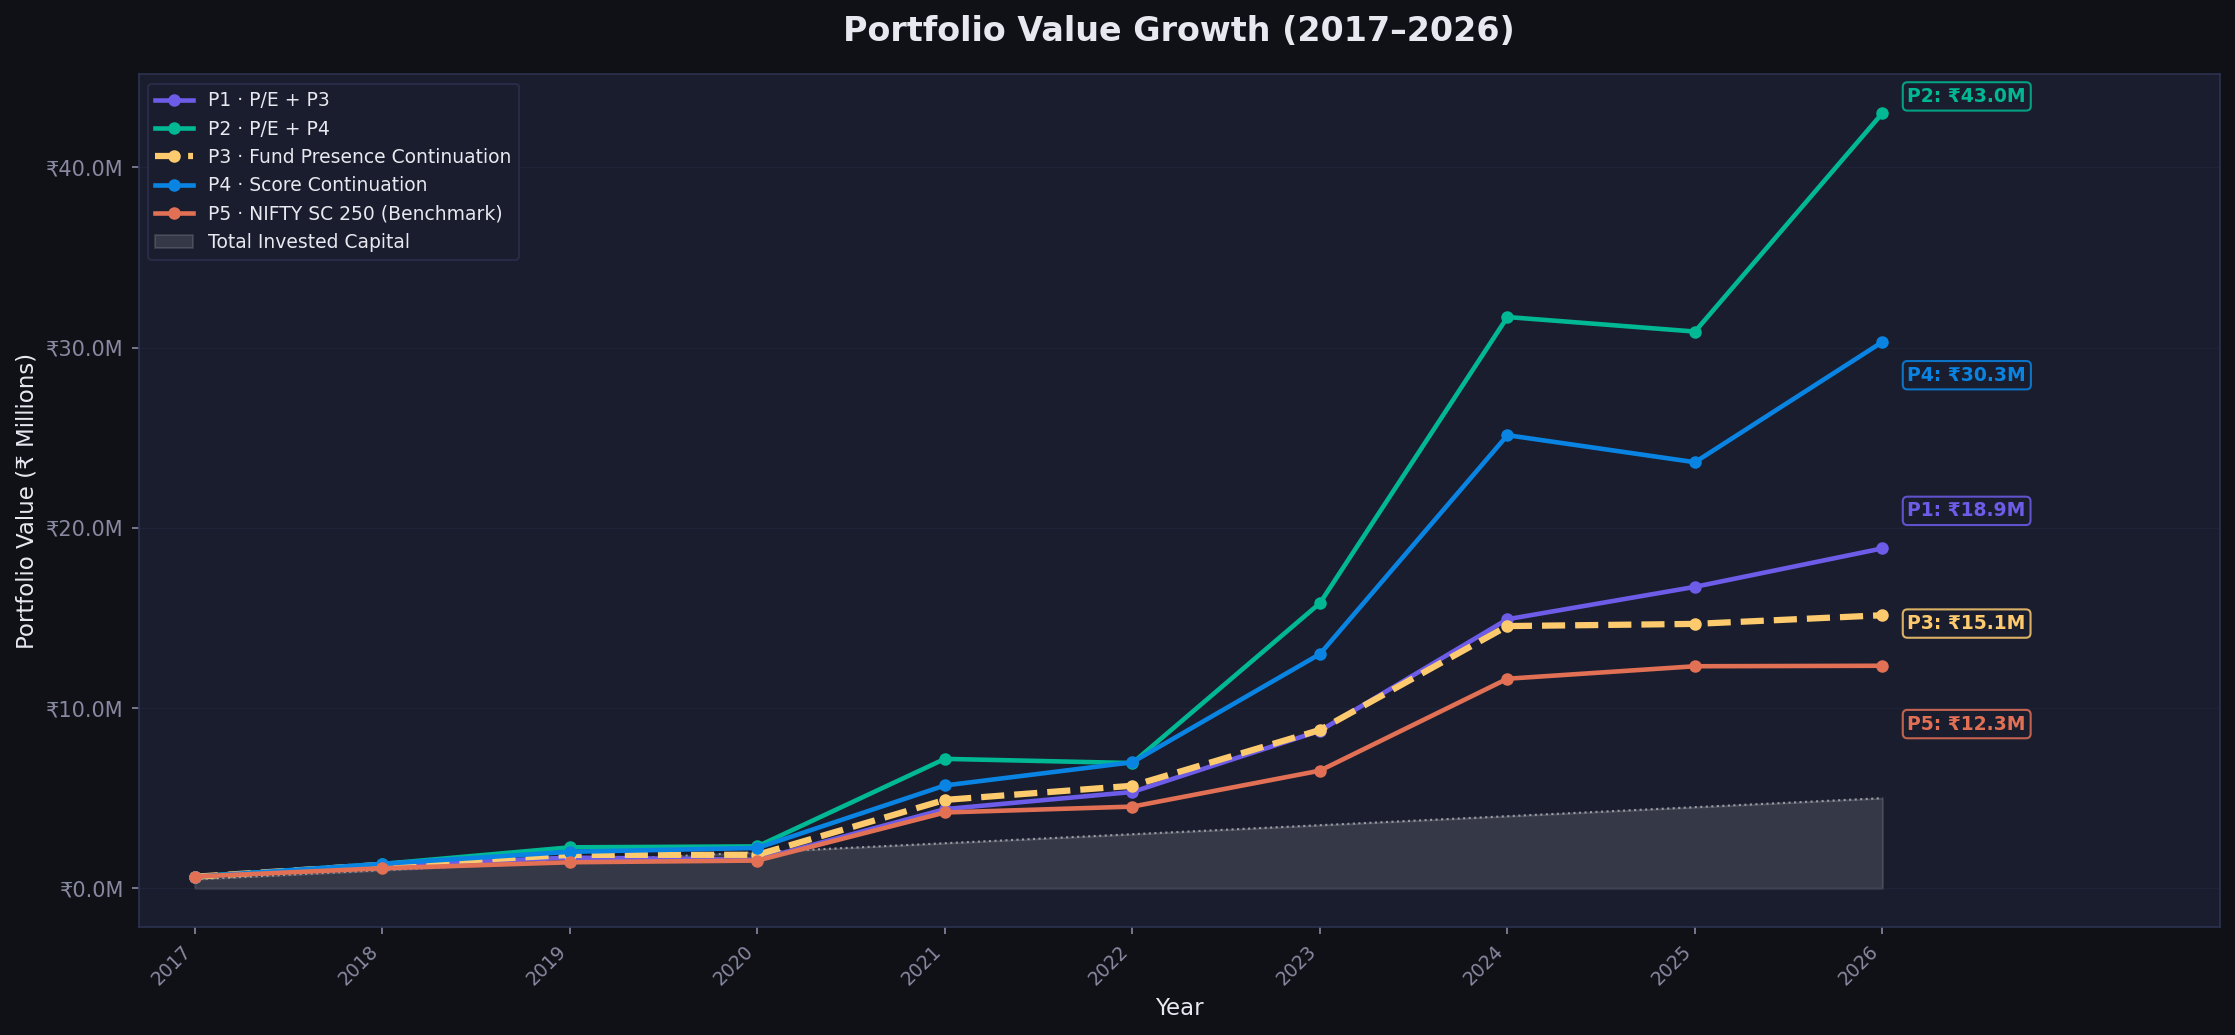

📁 Saved: chartP1_aum_growth.png


In [6]:
# ── Chart 1 — AUM Growth ──────────────────────────────────────────────────────
dark_style()
fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

for k in ['P1', 'P2', 'P3', 'P4', 'P5']:
    vals = [v / 1e6 for v in df[f'AUM_{k}']]
    ax.plot(
        years, vals,
        color=COLORS[k],
        lw=3 if k == 'P3' else 2.2,
        ls='--' if k == 'P3' else '-',
        label=LABELS[k],
        marker='o', ms=5, zorder=5
    )

inv_m = [v / 1e6 for v in invested]
ax.fill_between(years, inv_m, alpha=0.12, color='white', label='Total Invested Capital')
ax.plot(years, inv_m, color='white', lw=1, ls=':', alpha=0.5)

label_offsets = {'P1': 18, 'P2': 8, 'P3': -4, 'P4': -16, 'P5': -28}
for k in ['P1', 'P2', 'P3', 'P4', 'P5']:
    final_v = df[f'AUM_{k}'].iloc[-1] / 1e6
    ax.annotate(
        f'{k}: ₹{final_v:.1f}M',
        xy=(years[-1], final_v),
        xytext=(12, label_offsets[k]),
        textcoords='offset points',
        color=COLORS[k], fontsize=9, fontweight='bold',
        va='center', ha='left',
        bbox=dict(boxstyle='round,pad=0.25', facecolor=COLORS['panel'],
                  edgecolor=COLORS[k], alpha=0.85)
    )

ax.set_title('Portfolio Value Growth (2017–2026)',
             fontsize=16, fontweight='bold', color=COLORS['text'], pad=16)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Portfolio Value (₹ Millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.set_xlim(min(years) - 0.3, max(years) + 1.8)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig('chart1_aum_growth.png', dpi=150, bbox_inches='tight',
            facecolor=COLORS['bg'])
plt.show()
print('📁 Saved: chartP1_aum_growth.png')

---
## 📊 Chart 2 — XIRR & Alpha Dashboard
XIRR for each portfolio vs. the benchmark, with Alpha (excess return (XIRR over P5) highlighted.

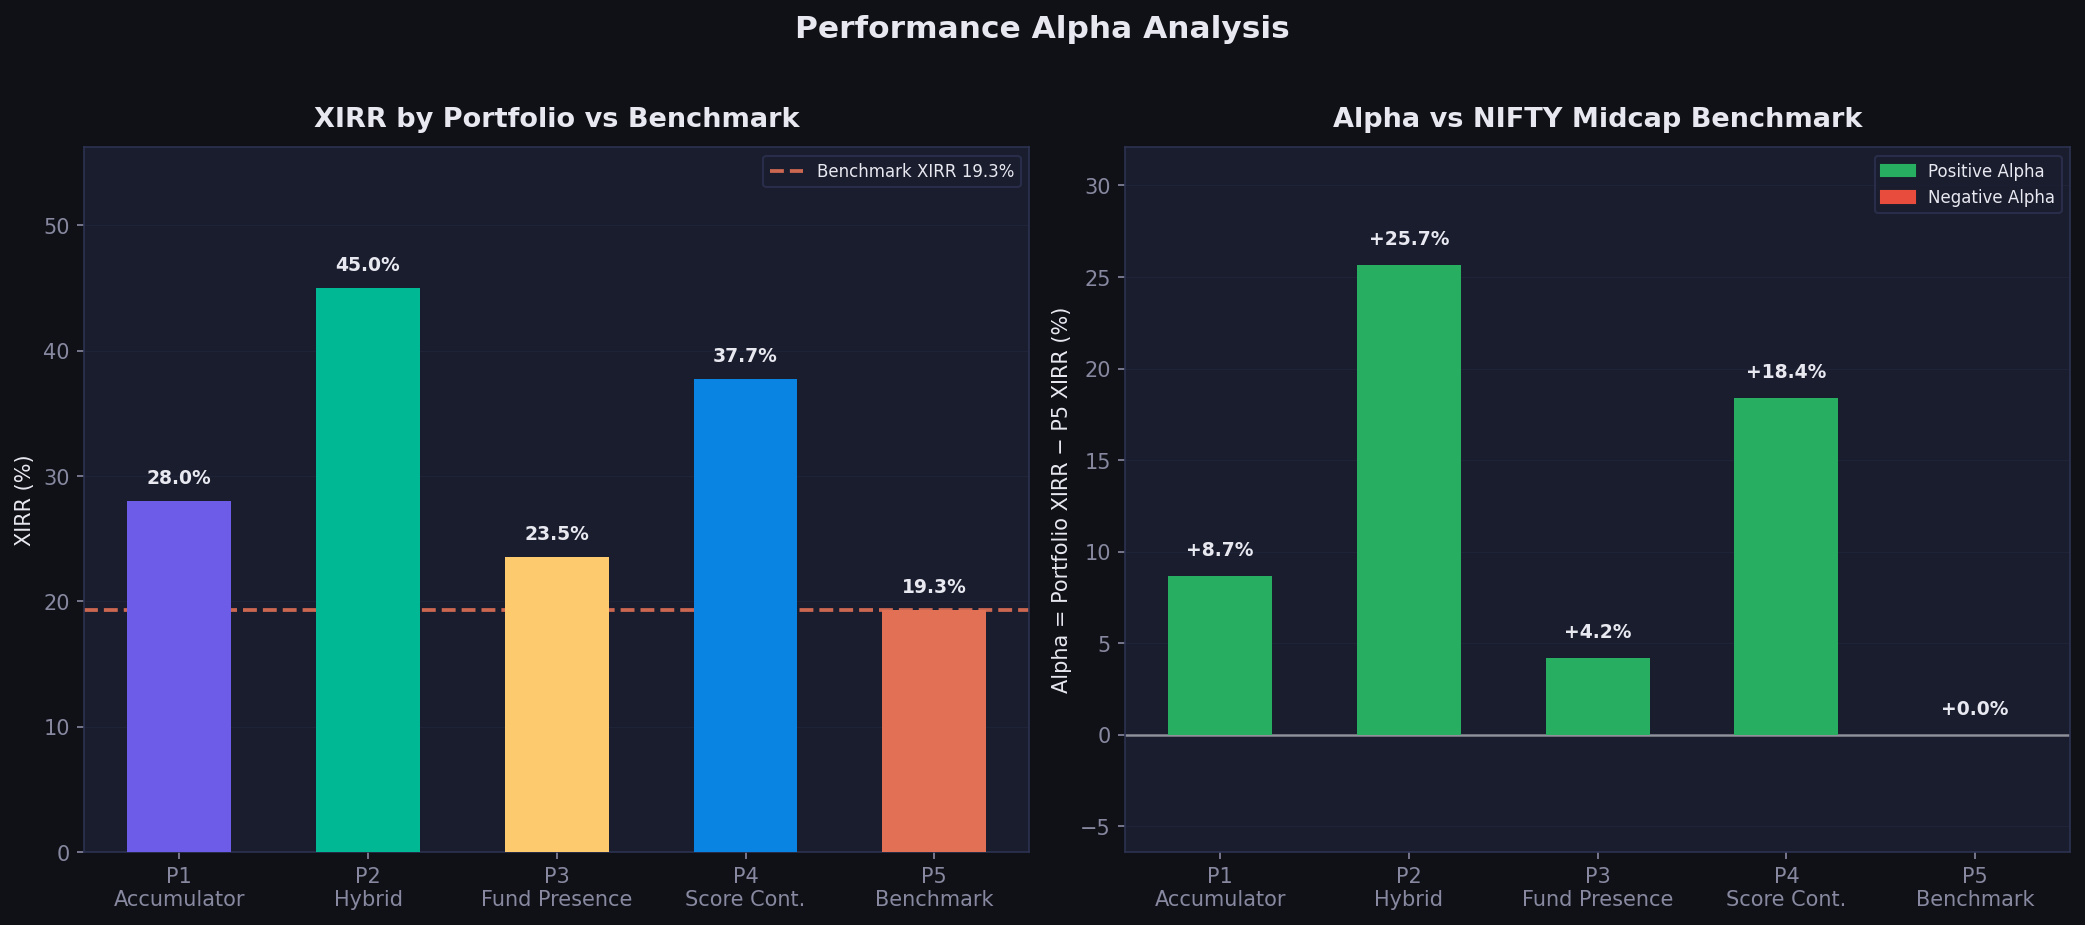

📁 Saved: chartM2_xirr_alpha.png


In [7]:
dark_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(COLORS['bg'])

# Correct strict order
keys = ['P1', 'P2', 'P3', 'P4', 'P5']

short_labels = [
    'P1\nAccumulator',
    'P2\nHybrid',
    'P3\nFund Presence',
    'P4\nScore Cont.',
    'P5\nBenchmark'
]

# Use XIRR, not CAGR, because this is yearly SIP-style investment
xirrs = [metrics[k]['XIRR %'] for k in keys]

benchmark_xirr = metrics['P5']['XIRR %']

# Alpha = XIRR of portfolio - XIRR of P5 benchmark
alphas = [metrics[k]['XIRR %'] - benchmark_xirr for k in keys]

colors_bar = [COLORS[k] for k in keys]


# ============================================================
# Chart 1 — XIRR by Portfolio
# ============================================================

ax1 = axes[0]
ax1.set_facecolor(COLORS['panel'])

bars = ax1.bar(
    short_labels,
    xirrs,
    color=colors_bar,
    width=0.55,
    zorder=3,
    edgecolor='none'
)

ax1.axhline(
    benchmark_xirr,
    color=COLORS['P5'],
    lw=1.8,
    ls='--',
    alpha=0.9,
    label=f'Benchmark XIRR {benchmark_xirr:.1f}%'
)

for bar, val in zip(bars, xirrs):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + max(xirrs) * 0.025,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=COLORS['text']
    )

ax1.set_title(
    'XIRR by Portfolio vs Benchmark',
    fontsize=13,
    fontweight='bold',
    color=COLORS['text'],
    pad=10
)

ax1.set_ylabel('XIRR (%)', fontsize=10)
ax1.grid(True, axis='y', alpha=0.3, zorder=0)
ax1.legend(fontsize=8)

ax1.set_ylim(
    min(0, min(xirrs) * 1.15),
    max(xirrs) * 1.25
)


# ============================================================
# Chart 2 — Alpha vs Benchmark
# Alpha = Portfolio XIRR - P5 XIRR
# ============================================================

ax2 = axes[1]
ax2.set_facecolor(COLORS['panel'])

alpha_colors = [
    '#27ae60' if a >= 0 else '#e74c3c'
    for a in alphas
]

bars2 = ax2.bar(
    short_labels,
    alphas,
    color=alpha_colors,
    width=0.55,
    zorder=3,
    edgecolor='none'
)

ax2.axhline(
    0,
    color='white',
    lw=1.2,
    alpha=0.5
)

for bar, val in zip(bars2, alphas):
    offset = max(abs(max(alphas)), abs(min(alphas))) * 0.035

    if val >= 0:
        y_pos = val + offset
        va_pos = 'bottom'
    else:
        y_pos = val - offset
        va_pos = 'top'

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        y_pos,
        f'{val:+.1f}%',
        ha='center',
        va=va_pos,
        fontsize=9,
        fontweight='bold',
        color=COLORS['text']
    )

ax2.set_title(
    'Alpha vs NIFTY Midcap Benchmark',
    fontsize=13,
    fontweight='bold',
    color=COLORS['text'],
    pad=10
)

ax2.set_ylabel('Alpha = Portfolio XIRR − P5 XIRR (%)', fontsize=10)
ax2.grid(True, axis='y', alpha=0.3, zorder=0)

green_patch = mpatches.Patch(color='#27ae60', label='Positive Alpha')
red_patch = mpatches.Patch(color='#e74c3c', label='Negative Alpha')

ax2.legend(
    handles=[green_patch, red_patch],
    fontsize=8
)

max_abs_alpha = max(abs(min(alphas)), abs(max(alphas)))

ax2.set_ylim(
    min(alphas) - max_abs_alpha * 0.25,
    max(alphas) + max_abs_alpha * 0.25
)


# ============================================================
# Final formatting
# ============================================================

fig.suptitle(
    'Performance Alpha Analysis',
    fontsize=15,
    fontweight='bold',
    color=COLORS['text'],
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'chart2_xirr_alpha.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM2_xirr_alpha.png")

---
## 📊 Chart 3 — Annual Return Heatmap
Colour-coded grid: year × portfolio, with intensity showing magnitude of gain/loss.

In [8]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

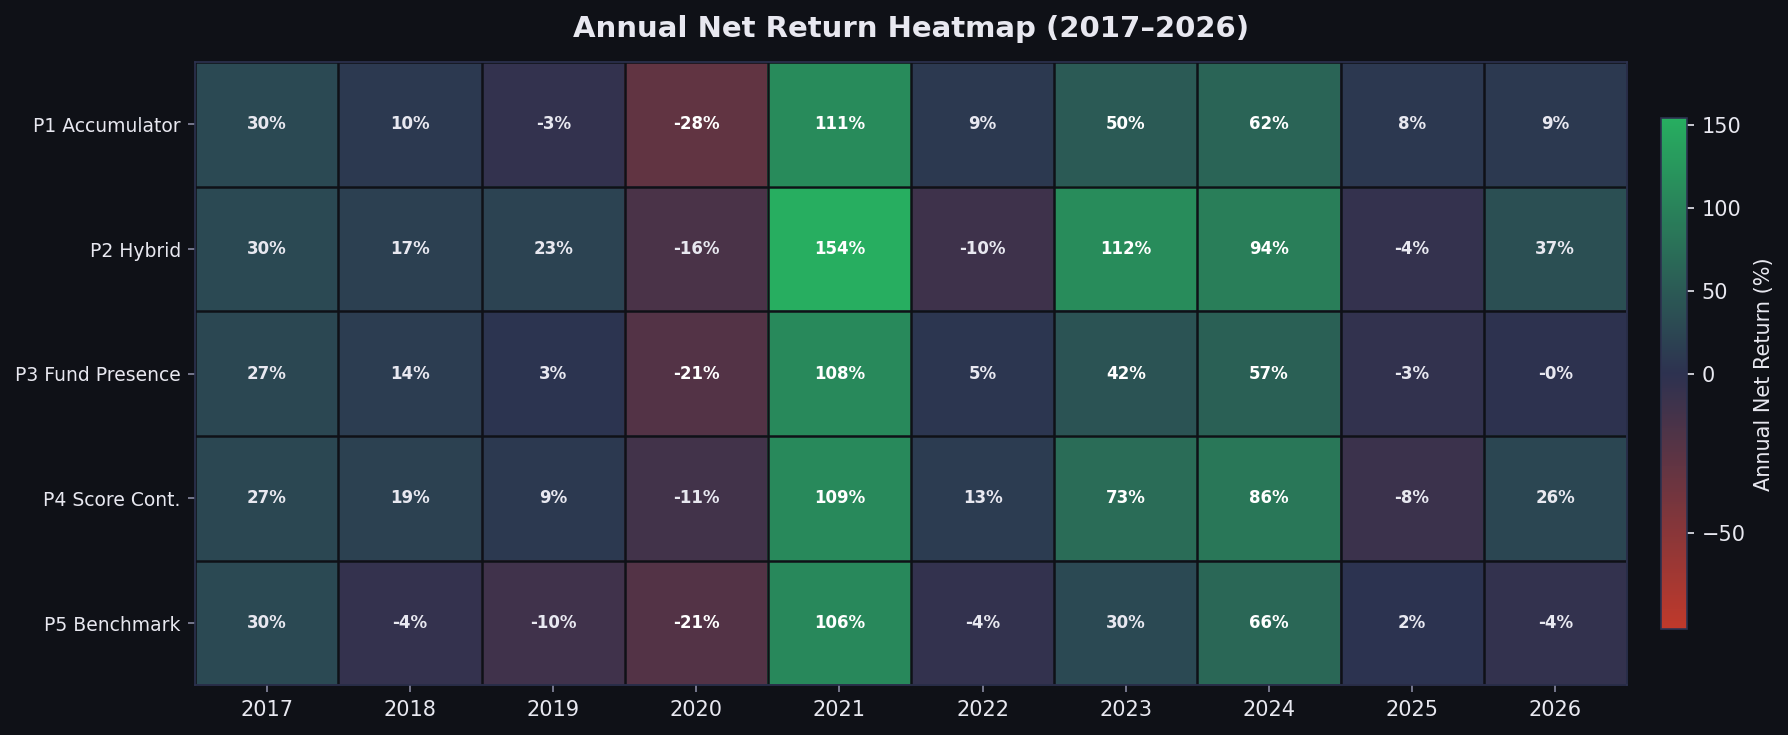

📁 Saved: chartM3_return_heatmap.png


In [9]:
dark_style()

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

# Correct portfolio order
keys = ['P1', 'P2', 'P3', 'P4', 'P5']

row_labels = [
    'P1 Accumulator',
    'P2 Hybrid',
    'P3 Fund Presence',
    'P4 Score Cont.',
    'P5 Benchmark'
]

# Build heatmap matrix: rows = portfolios, columns = years
heat_data = np.array([
    [net_ret[k][i] for i in range(N)]
    for k in keys
])

# ============================================================
# Better color scale
# Red = negative, dark neutral = zero, green = positive
# Center color exactly at 0
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    'return_red_black_green',
    [
        '#c0392b',   # negative red
        '#2d3250',   # neutral dark
        '#27ae60'    # positive green
    ]
)

max_abs = np.nanmax(np.abs(heat_data))

# Cap extreme values so one very high return does not destroy color balance
vmin = max(-80, -max_abs)
vmax = min(180, max_abs)

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

im = ax.imshow(
    heat_data,
    aspect='auto',
    cmap=cmap,
    norm=norm
)

# Labels
ax.set_xticks(range(N))
ax.set_xticklabels(years, fontsize=10, color=COLORS['text'])

ax.set_yticks(range(len(keys)))
ax.set_yticklabels(row_labels, fontsize=9, color=COLORS['text'])

# Annotate each cell
for r in range(len(keys)):
    for c in range(N):
        val = heat_data[r, c]

        # Better text color based on cell value
        if val <= -20 or val >= 40:
            txt_col = 'white'
        else:
            txt_col = COLORS['text']

        ax.text(
            c,
            r,
            f'{val:.0f}%',
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color=txt_col
        )

# Cell borders
ax.set_xticks(np.arange(-0.5, N, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(keys), 1), minor=True)

ax.grid(
    which='minor',
    color=COLORS['bg'],
    linestyle='-',
    linewidth=1.2
)

ax.tick_params(which='minor', bottom=False, left=False)

# Colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    shrink=0.82,
    pad=0.02
)

cbar.set_label(
    'Annual Net Return (%)',
    color=COLORS['text'],
    fontsize=10
)

cbar.ax.yaxis.set_tick_params(color=COLORS['text'])
plt.setp(cbar.ax.get_yticklabels(), color=COLORS['text'])

# Title
ax.set_title(
    'Annual Net Return Heatmap (2017–2026)',
    fontsize=14,
    fontweight='bold',
    color=COLORS['text'],
    pad=12
)

plt.tight_layout()

plt.savefig(
    'chart3_return_heatmap.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM3_return_heatmap.png")

---
## 📊 Chart 4 — Yearly Profit/Loss Bars
Yearly absolute profit (₹) for each portfolio — showing which years contributed most gains.

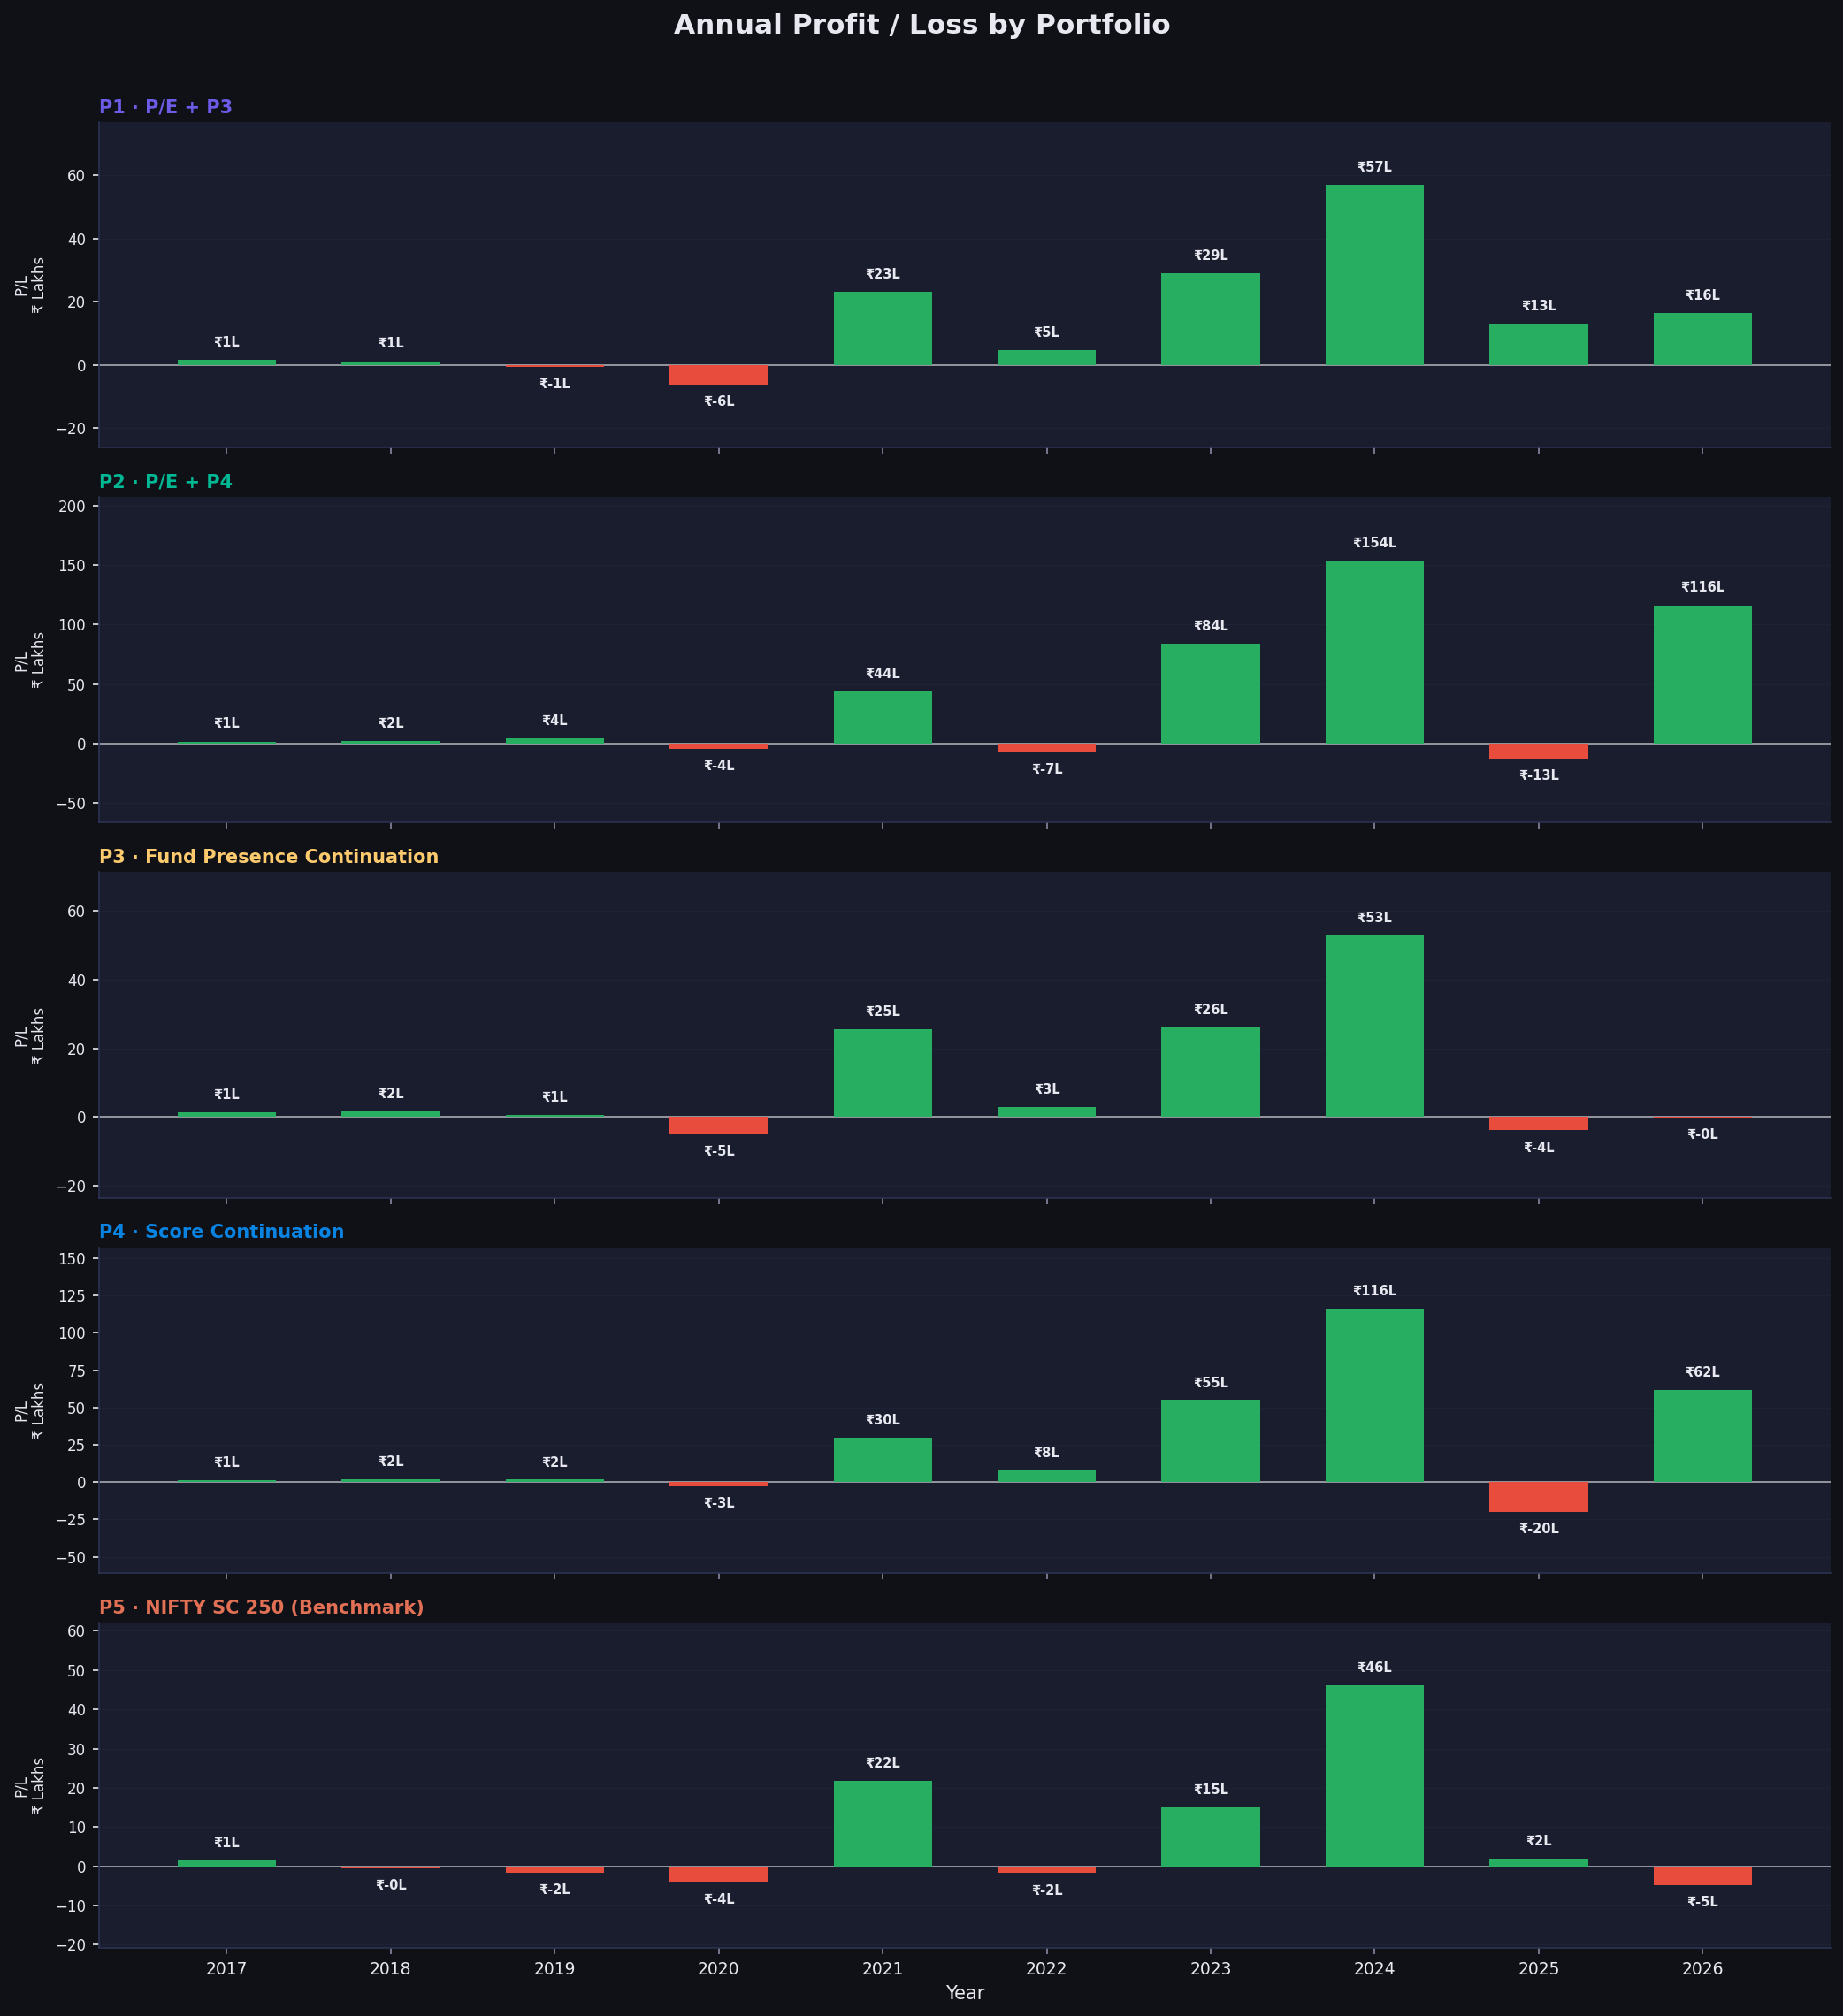

📁 Saved: chartM4_yearly_pnl.png


In [10]:
dark_style()

keys = ['P1', 'P2', 'P3', 'P4', 'P5']

fig, axes = plt.subplots(
    5, 1,
    figsize=(14, 15),
    sharex=True
)

fig.patch.set_facecolor(COLORS['bg'])

for idx, k in enumerate(keys):

    ax = axes[idx]
    ax.set_facecolor(COLORS['panel'])

    # Profit/Loss in ₹ Lakhs
    vals_lakh = [v / 1e5 for v in profit[k]]

    bar_colors = [
        '#27ae60' if v >= 0 else '#e74c3c'
        for v in vals_lakh
    ]

    bars = ax.bar(
        years,
        vals_lakh,
        color=bar_colors,
        width=0.60,
        zorder=3,
        edgecolor='none'
    )

    ax.axhline(
        0,
        color='white',
        lw=0.9,
        alpha=0.55,
        zorder=2
    )

    # Dynamic y-limit
    max_abs = max(abs(min(vals_lakh)), abs(max(vals_lakh)))

    if max_abs == 0:
        max_abs = 1

    ax.set_ylim(
        min(vals_lakh) - max_abs * 0.35,
        max(vals_lakh) + max_abs * 0.35
    )

    ax.set_ylabel(
        'P/L\n₹ Lakhs',
        fontsize=8,
        color=COLORS['text']
    )

    ax.set_title(
        LABELS[k],
        fontsize=10,
        fontweight='bold',
        color=COLORS[k],
        loc='left',
        pad=5
    )

    ax.grid(
        True,
        axis='y',
        alpha=0.25,
        zorder=0
    )

    # Bar labels
    for bar, val in zip(bars, vals_lakh):

        offset = max_abs * 0.06

        if val >= 0:
            y_pos = val + offset
            va_pos = 'bottom'
        else:
            y_pos = val - offset
            va_pos = 'top'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            f'₹{val:.0f}L',
            ha='center',
            va=va_pos,
            fontsize=7,
            fontweight='bold',
            color=COLORS['text']
        )

    # Cleaner axis style
    ax.tick_params(
        axis='y',
        labelsize=8,
        colors=COLORS['text']
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# X-axis
axes[-1].set_xticks(years)
axes[-1].set_xticklabels(
    years,
    fontsize=9,
    color=COLORS['text']
)

axes[-1].set_xlabel(
    'Year',
    fontsize=10,
    color=COLORS['text']
)

fig.suptitle(
    'Annual Profit / Loss by Portfolio',
    fontsize=15,
    fontweight='bold',
    color=COLORS['text'],
    y=1.01
)

plt.tight_layout()

plt.savefig(
    'chart4_yearly_pnl.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM4_yearly_pnl.png")

---
## 📊 Chart 5 — Risk-Return Bubble Chart
Each portfolio is plotted by XIRR (x-axis) vs. Max Drawdown (y-axis). Bubble size = Final AUM. Ideal = Bottam-left.

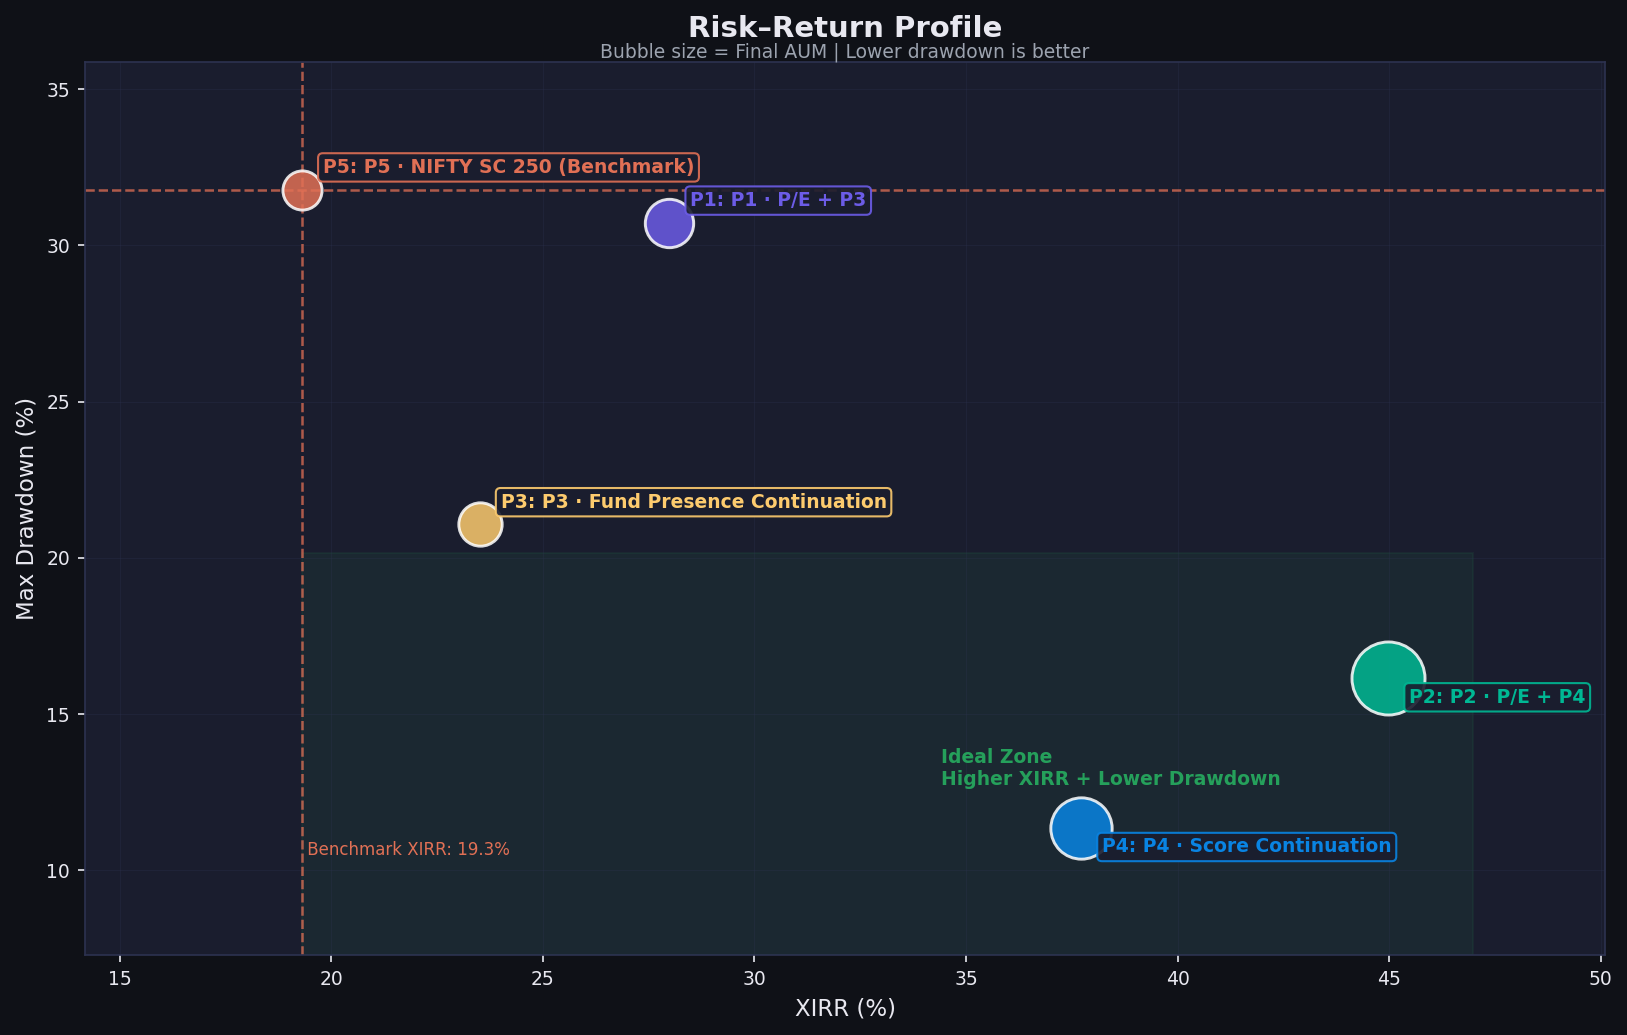

📁 Saved: chartM5_risk_return.png


In [11]:
dark_style()

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

# Strict order
keys = ['P1', 'P2', 'P3', 'P4', 'P5']

# Use XIRR, not CAGR, because portfolio has yearly investments
x_vals = [metrics[k]['XIRR %'] for k in keys]

# Risk = Max Drawdown
y_vals = [metrics[k]['Max Drawdown %'] for k in keys]

# Bubble size = Final AUM
sizes = [
    max(metrics[k]['Final AUM'] / 35000, 120)
    for k in keys
]

# Plot bubbles
for k, x, y, sz in zip(keys, x_vals, y_vals, sizes):

    ax.scatter(
        x,
        y,
        s=sz,
        color=COLORS[k],
        alpha=0.85,
        edgecolors='white',
        linewidths=1.4,
        zorder=5
    )

# ============================================================
# Labels with manual offsets to avoid overlap
# ============================================================

label_offsets = {
    'P1': (10, 8),
    'P2': (10, -12),
    'P3': (10, 8),
    'P4': (10, -12),
    'P5': (10, 8)
}

for k, x, y in zip(keys, x_vals, y_vals):

    dx, dy = label_offsets[k]

    ax.annotate(
        f"{k}: {LABELS[k]}",
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        color=COLORS[k],
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor=COLORS['panel'],
            edgecolor=COLORS[k],
            alpha=0.90
        ),
        zorder=10
    )


# ============================================================
# Benchmark reference lines
# ============================================================

benchmark_xirr = metrics['P5']['XIRR %']
benchmark_dd = metrics['P5']['Max Drawdown %']

ax.axvline(
    benchmark_xirr,
    color=COLORS['P5'],
    lw=1.2,
    ls='--',
    alpha=0.75
)

ax.axhline(
    benchmark_dd,
    color=COLORS['P5'],
    lw=1.2,
    ls='--',
    alpha=0.75
)

ax.text(
    benchmark_xirr,
    ax.get_ylim()[0],
    f' Benchmark XIRR: {benchmark_xirr:.1f}%',
    color=COLORS['P5'],
    fontsize=8,
    va='bottom',
    ha='left'
)


# ============================================================
# Ideal zone: High XIRR + Low Drawdown
# Since y-axis is inverted, lower drawdown is visually higher.
# ============================================================

x_min = min(x_vals)
x_max = max(x_vals)
y_min = min(y_vals)
y_max = max(y_vals)

ax.axvspan(
    benchmark_xirr,
    x_max + 2,
    ymin=0,
    ymax=0.45,
    alpha=0.08,
    color='#27ae60',
    zorder=0
)

ax.text(
    0.563,
    0.19,
    'Ideal Zone\nHigher XIRR + Lower Drawdown',
    transform=ax.transAxes,
    color='#27ae60',
    fontsize=9,
    fontweight='bold',
    alpha=0.9
)


# ============================================================
# Axis formatting
# ============================================================

ax.set_xlabel(
    'XIRR (%)',
    fontsize=11,
    color=COLORS['text']
)

ax.set_ylabel(
    'Max Drawdown (%)',
    fontsize=11,
    color=COLORS['text']
)

ax.set_title(
    'Risk–Return Profile',
    fontsize=14,
    fontweight='bold',
    color=COLORS['text'],
    pad=12
)

ax.text(
    0.5,
    1.0001,
    'Bubble size = Final AUM | Lower drawdown is better',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9,
    color=COLORS.get('muted', '#9ca3af')
)

ax.grid(True, alpha=0.30)

# Add padding
x_pad = max((x_max - x_min) * 0.20, 2)
y_pad = max((y_max - y_min) * 0.20, 2)

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_max + y_pad, max(0, y_min - y_pad))  # inverted axis

# Lower drawdown should appear at top
ax.invert_yaxis()

ax.tick_params(
    axis='both',
    colors=COLORS['text'],
    labelsize=9
)

plt.tight_layout()

plt.savefig(
    'chart5_risk_return.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM5_risk_return.png")

---
## 📊 Chart 6 — Cumulative Wealth Multiple
How many times each portfolio multiplied the total invested capital.

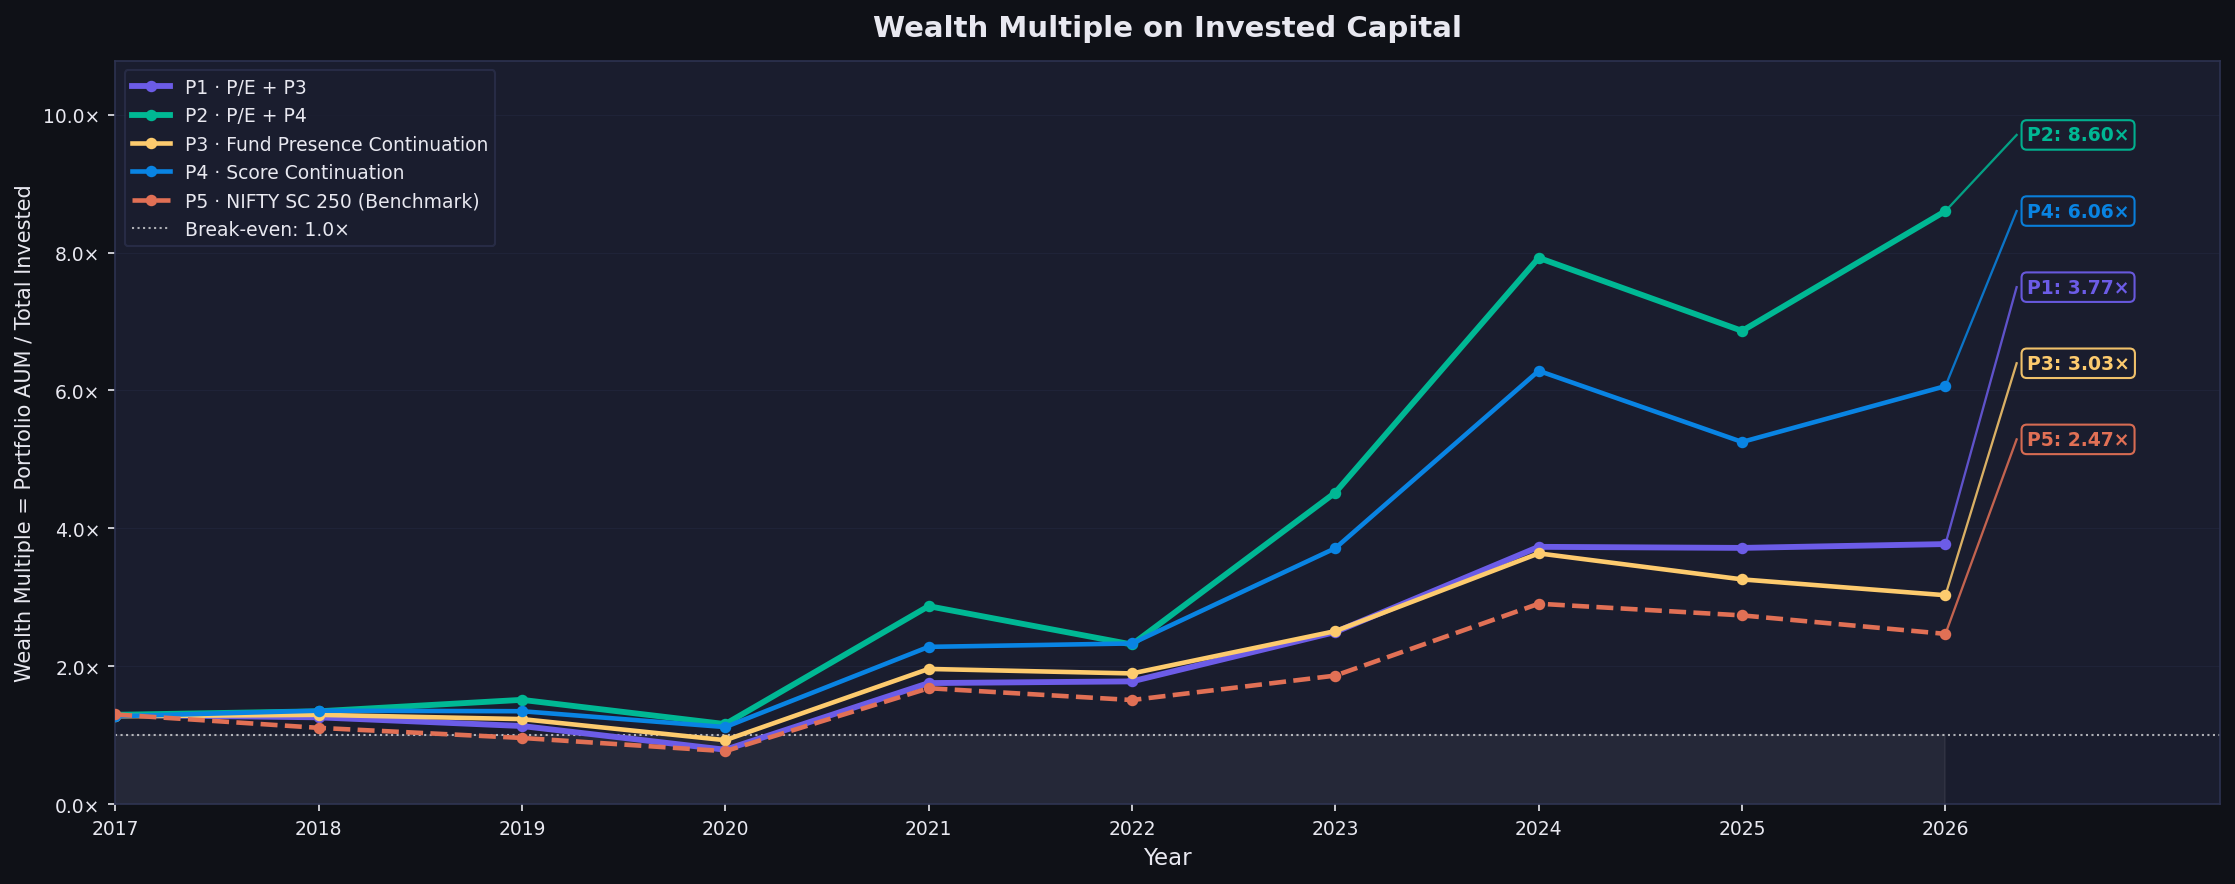

📁 Saved: chartM6_wealth_multiple.png


In [12]:
dark_style()

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['panel'])

keys = ['P1', 'P2', 'P3', 'P4', 'P5']

# ============================================================
# Wealth multiple = AUM / cumulative invested capital
# ============================================================

for k in keys:
    multiples = [
        df[f'AUM_{k}'].iloc[i] / df['Invested'].iloc[i]
        for i in range(N)
    ]

    lw = 2.8 if k in ['P1', 'P2'] else 2.2
    ls = '--' if k == 'P5' else '-'

    ax.plot(
        years,
        multiples,
        color=COLORS[k],
        lw=lw,
        ls=ls,
        label=LABELS[k],
        marker='o',
        ms=4.5,
        zorder=5
    )


# ============================================================
# Final labels — stacked right side to avoid merging
# ============================================================

final_multiples = {
    k: df[f'AUM_{k}'].iloc[-1] / df['Invested'].iloc[-1]
    for k in keys
}

sorted_keys = sorted(
    keys,
    key=lambda k: final_multiples[k],
    reverse=True
)

max_final = max(final_multiples.values())
min_final = min(final_multiples.values())

label_gap = max((max_final - min_final) * 0.18, 0.12)

label_positions = {}

start_y = max_final + label_gap

for i, k in enumerate(sorted_keys):
    label_positions[k] = start_y - i * label_gap

for k in sorted_keys:
    final_y = final_multiples[k]
    label_y = label_positions[k]

    # Connector line
    ax.plot(
        [years[-1], years[-1] + 0.35],
        [final_y, label_y],
        color=COLORS[k],
        lw=1.1,
        alpha=0.85,
        zorder=4
    )

    # Label box
    ax.text(
        years[-1] + 0.40,
        label_y,
        f'{k}: {final_y:.2f}×',
        color=COLORS[k],
        fontsize=9,
        fontweight='bold',
        va='center',
        ha='left',
        bbox=dict(
            boxstyle='round,pad=0.28',
            facecolor=COLORS['panel'],
            edgecolor=COLORS[k],
            alpha=0.95
        ),
        zorder=10
    )


# ============================================================
# Break-even line
# ============================================================

ax.axhline(
    1.0,
    color='white',
    lw=1,
    ls=':',
    alpha=0.65,
    label='Break-even: 1.0×'
)

ax.fill_between(
    years,
    1.0,
    alpha=0.05,
    color='white'
)


# ============================================================
# Formatting
# ============================================================

ax.set_title(
    'Wealth Multiple on Invested Capital',
    fontsize=14,
    fontweight='bold',
    color=COLORS['text'],
    pad=12
)

ax.set_xlabel(
    'Year',
    fontsize=11,
    color=COLORS['text']
)

ax.set_ylabel(
    'Wealth Multiple = Portfolio AUM / Total Invested',
    fontsize=10,
    color=COLORS['text']
)

ax.set_xticks(years)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}×')
)

ax.grid(
    True,
    axis='y',
    alpha=0.3
)

# Add space on right for labels
ax.set_xlim(min(years), max(years) + 1.35)

all_y = []

for k in keys:
    all_y.extend([
        df[f'AUM_{k}'].iloc[i] / df['Invested'].iloc[i]
        for i in range(N)
    ])

all_y.extend(label_positions.values())

y_min = min(all_y)
y_max = max(all_y)

y_pad = max((y_max - y_min) * 0.12, 0.15)

ax.set_ylim(
    max(0, y_min - y_pad),
    y_max + y_pad
)

ax.tick_params(
    axis='both',
    colors=COLORS['text'],
    labelsize=9
)

ax.legend(
    fontsize=9,
    loc='upper left',
    framealpha=0.7
)

plt.tight_layout()

plt.savefig(
    'chart6_wealth_multiple.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM6_wealth_multiple.png")

---
## 📊 Chart 7 — Comprehensive Metrics Summary Table
Side-by-side scorecard with all key metrics.

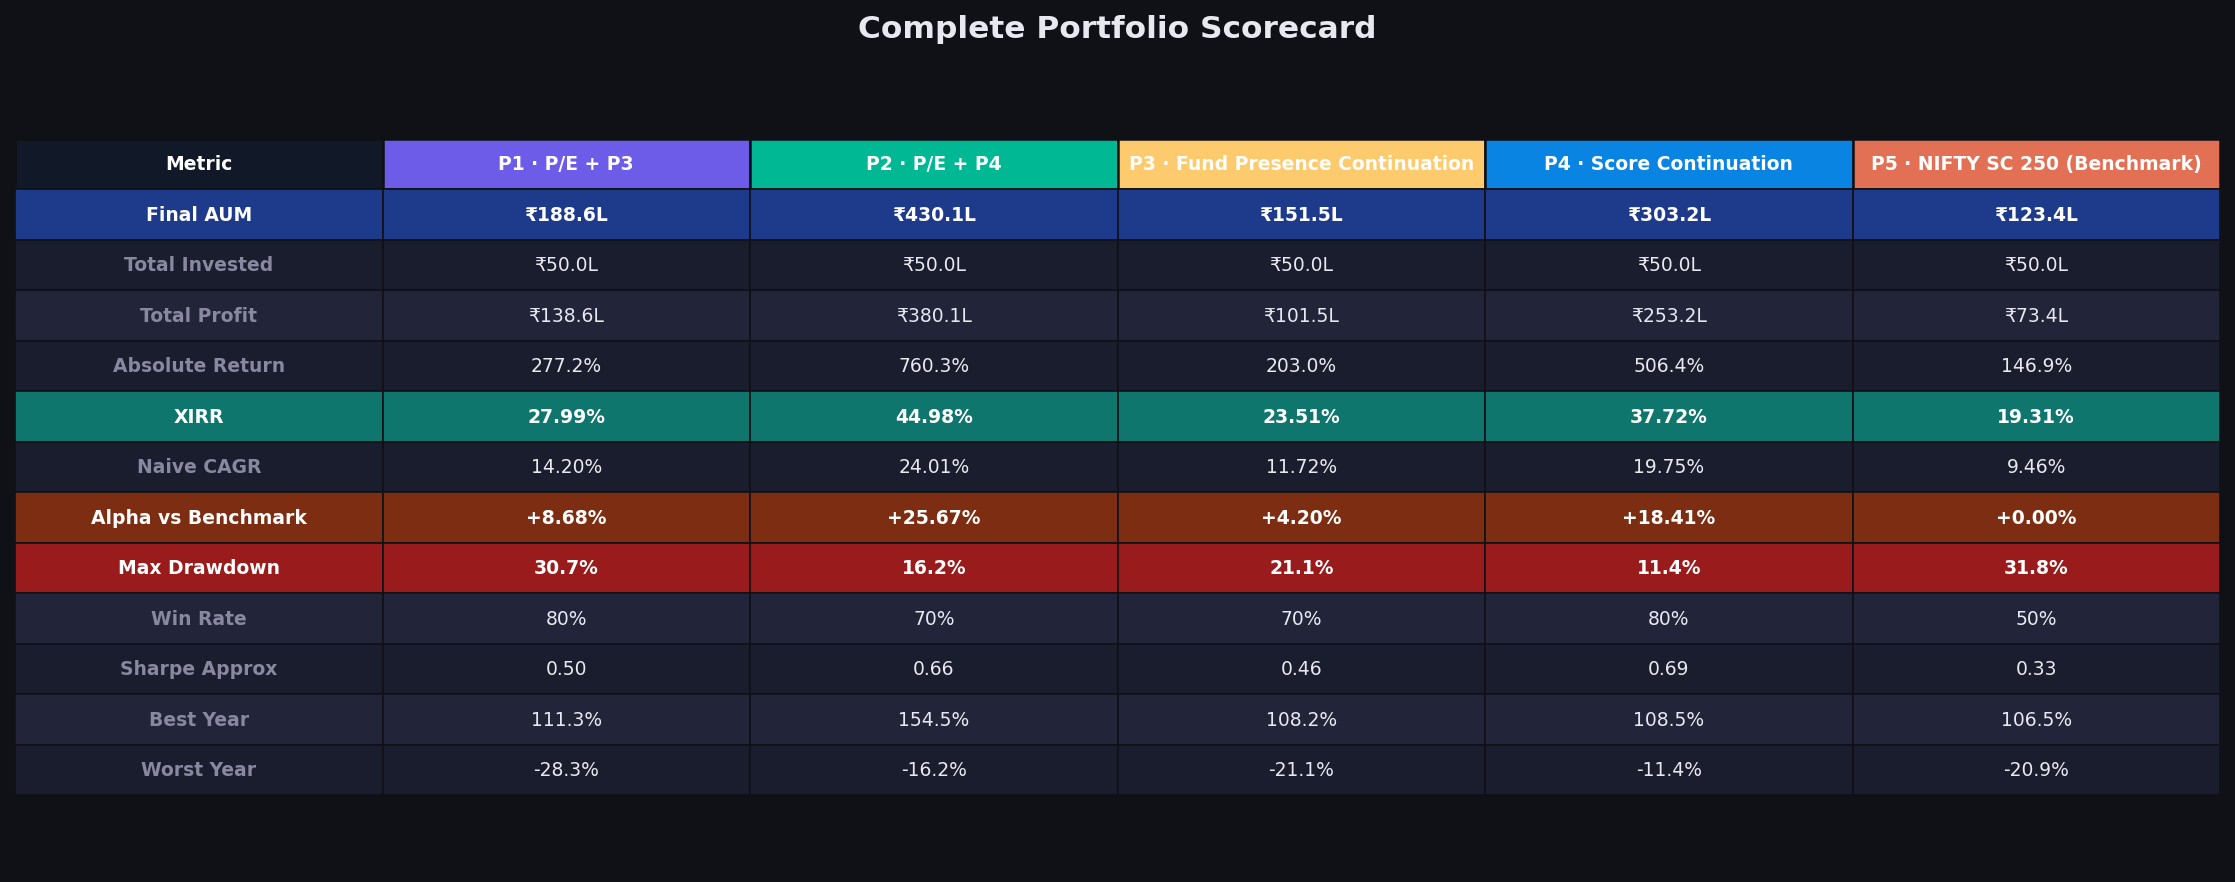

📁 Saved: chartM7_scorecard.png


In [13]:
dark_style()

fig, ax = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor(COLORS['bg'])
ax.set_facecolor(COLORS['bg'])
ax.axis('off')

# ============================================================
# Correct Portfolio Order
# ============================================================

port_keys_order = ['P1', 'P2', 'P3', 'P4', 'P5']

# ============================================================
# Scorecard Rows
# Use XIRR instead of CAGR because this is SIP/yearly investment
# Alpha = Portfolio XIRR - P5 XIRR
# ============================================================

metric_rows = [
    ('Final AUM',              lambda k: f"₹{metrics[k]['Final AUM'] / 1e5:,.1f}L"),
    ('Total Invested',         lambda k: f"₹{metrics[k]['Total Invested'] / 1e5:,.1f}L"),
    ('Total Profit',           lambda k: f"₹{metrics[k]['Total Profit'] / 1e5:,.1f}L"),
    ('Absolute Return',        lambda k: f"{metrics[k]['Abs Return %']:.1f}%"),
    ('XIRR',                   lambda k: f"{metrics[k]['XIRR %']:.2f}%"),
    ('Naive CAGR',             lambda k: f"{metrics[k]['Naive CAGR %']:.2f}%"),
    ('Alpha vs Benchmark',     lambda k: f"{metrics[k]['Alpha vs Benchmark %']:+.2f}%"),
    ('Max Drawdown',           lambda k: f"{metrics[k]['Max Drawdown %']:.1f}%"),
    ('Win Rate',               lambda k: f"{metrics[k]['Win Rate %']:.0f}%"),
    ('Sharpe Approx',          lambda k: f"{metrics[k]['Sharpe Approx']:.2f}"),
    ('Best Year',              lambda k: f"{metrics[k]['Best Year %']:.1f}%"),
    ('Worst Year',             lambda k: f"{metrics[k]['Worst Year %']:.1f}%"),
]

# ============================================================
# Table Data
# ============================================================

col_headers = ['Metric'] + [LABELS[k] for k in port_keys_order]

table_data = []

for label, fn in metric_rows:
    row = [label] + [fn(k) for k in port_keys_order]
    table_data.append(row)

# ============================================================
# Create Table
# ============================================================

tbl = ax.table(
    cellText=table_data,
    colLabels=col_headers,
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.75)

# ============================================================
# Header Styling
# ============================================================

for c in range(len(col_headers)):
    cell = tbl[(0, c)]

    if c == 0:
        cell.set_facecolor('#111827')
    else:
        k = port_keys_order[c - 1]
        cell.set_facecolor(COLORS.get(k, '#2D3250'))

    cell.set_text_props(
        color='white',
        fontweight='bold'
    )

    cell.set_edgecolor(COLORS.get('bg', '#0B1020'))
    cell.set_linewidth(1.2)

# ============================================================
# Body Styling
# ============================================================

for r in range(1, len(table_data) + 1):

    bg = '#1A1D2E' if r % 2 == 0 else '#22253A'

    for c in range(len(col_headers)):

        cell = tbl[(r, c)]
        cell.set_facecolor(bg)
        cell.set_edgecolor(COLORS.get('bg', '#0B1020'))
        cell.set_linewidth(0.8)

        if c == 0:
            cell.set_text_props(
                color=COLORS.get('subtext', '#cbd5e1'),
                fontweight='bold'
            )
        else:
            cell.set_text_props(
                color=COLORS.get('text', 'white')
            )

# ============================================================
# Highlight Important Rows
# ============================================================

important_rows = {
    'XIRR': '#0f766e',
    'Alpha vs Benchmark': '#7c2d12',
    'Max Drawdown': '#991b1b',
    'Final AUM': '#1e3a8a'
}

for r, row in enumerate(table_data, start=1):
    metric_name = row[0]

    if metric_name in important_rows:
        for c in range(len(col_headers)):
            cell = tbl[(r, c)]
            cell.set_facecolor(important_rows[metric_name])
            cell.set_text_props(
                color='white',
                fontweight='bold'
            )

# ============================================================
# Title
# ============================================================

ax.set_title(
    'Complete Portfolio Scorecard',
    fontsize=15,
    fontweight='bold',
    color=COLORS.get('text', 'white'),
    pad=22,
    y=0.98
)

plt.tight_layout()

plt.savefig(
    'chart7_scorecard.png',
    dpi=150,
    bbox_inches='tight',
    facecolor=COLORS['bg']
)

plt.show()

print("📁 Saved: chartM7_scorecard.png")